In [1]:
#Practicing statistics in python here ...

# Import numpy with alias np and pandas as pd
import numpy as np
import pandas as pd

insurance_df = pd.read_csv("Data/insurance.csv")
insurance_df.shape
insurance_df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
# Subset sex for female: female
female_insur = insurance_df[insurance_df['sex'] == 'female']

# Calculate mean charges for females
print("Mean:", np.mean(female_insur['charges']))

# Calculate median charges for females
print("Median:", np.median(female_insur['charges']))

Mean: 12569.578843835347
Median: 9412.9625


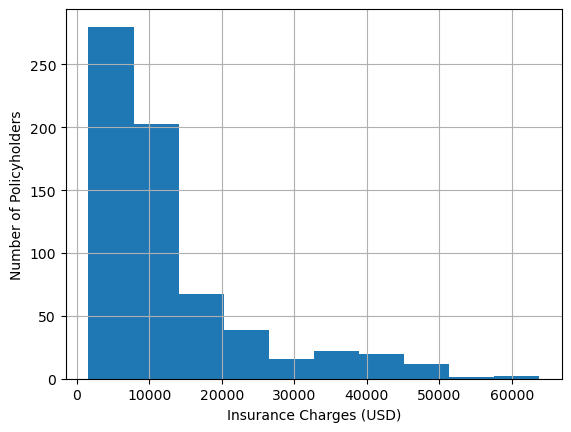

In [3]:
import matplotlib.pyplot as plt

# Subset for female
female_insur = insurance_df[insurance_df['sex'] == 'female']

# Histogram of charges for females
female_insur['charges'].hist()
plt.xlabel('Insurance Charges (USD)')
plt.ylabel('Number of Policyholders')
plt.show()

Analysis: the mean (12,569.58) is higher than ($9,412.96), indicating a right-skewed distribution. A small number of females with very high medical charges pull the mean upward, making the median a more reliable measure of the typical female policyholder's charges.


                 var           std
sex                               
female  1.238480e+08  11128.703801
male    1.682475e+08  12971.025915


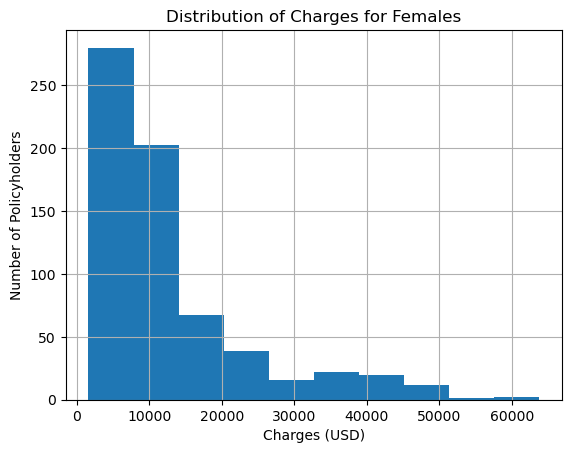

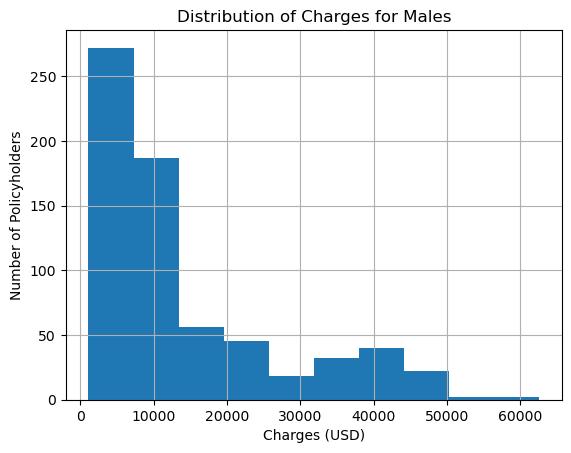

In [4]:
# Print variance and sd of charges for each sex
print(insurance_df.groupby('sex')['charges'].agg(['var', 'std']))

# Create histogram of charges for 'female'
insurance_df[insurance_df['sex'] == 'female']['charges'].hist()
plt.xlabel('Charges (USD)')
plt.ylabel('Number of Policyholders')
plt.title('Distribution of Charges for Females')
plt.show()

# Create histogram of charges for 'male'
plt.figure()
insurance_df[insurance_df['sex'] == 'male']['charges'].hist()
plt.xlabel('Charges (USD)')
plt.ylabel('Number of Policyholders')
plt.title('Distribution of Charges for Males')
plt.show()

In [5]:
print(np.quantile(insurance_df['charges'], [0, 0.25, 0.5, 0.75, 1]))
# Calculate the deciles of charges
print(np.quantile(insurance_df['charges'], [0, 0.1, 0.2, 0.3, 0.4, 0.5,0.6, 0.7,0.8, 0.9,1]))

[ 1121.8739    4740.28715   9382.033    16639.912515 63770.42801 ]
[ 1121.8739    2346.533615  3991.57572   5484.84677   7369.05273
  9382.033    11399.85716  13767.875345 20260.626406 34831.7197
 63770.42801 ]


In [6]:
# Calculate total charges per region: charges_by_region
churn_df = pd.read_csv('Data/telecom_churn.csv')
print(churn_df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [7]:
# Calculate total MonthlyCharges per Contract type
charges_by_contract = churn_df.groupby('Contract')['MonthlyCharges'].sum()

# Compute the first and third quantiles and IQR
q1 = np.quantile(charges_by_contract, 0.25)
q3 = np.quantile(charges_by_contract, 0.75)
iqr = q3 - q1

# Calculate the lower and upper cutoffs for outliers
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# Subset to find outliers
outliers = charges_by_contract[(charges_by_contract < lower) | (charges_by_contract > upper)]
print(outliers)
#No outliers found

Series([], Name: MonthlyCharges, dtype: float64)


In [8]:
amir_deals = pd.read_csv('Data/amir_deals.csv')

# Count the deals for each product
counts = amir_deals['product'].value_counts()

# Calculate probability of picking a deal with each product
probs = amir_deals['product'].value_counts() / amir_deals.shape[0]
print(probs)


product
Product B    0.348315
Product D    0.224719
Product A    0.129213
Product C    0.084270
Product F    0.061798
Product H    0.044944
Product I    0.039326
Product E    0.028090
Product N    0.016854
Product G    0.011236
Product J    0.011236
Name: count, dtype: float64


In [9]:
# Set random seed
np.random.seed(24)

# Sample 5 deals with replacement
sample_with_replacement = amir_deals.sample(5, replace = True)
print(sample_with_replacement)

     Unnamed: 0    product   client status   amount  num_users
162         163  Product D  Current    Won  6755.66         59
131         132  Product B  Current    Won  6872.29         25
87           88  Product C  Current    Won  3579.63          3
145         146  Product A  Current    Won  4682.94         63
145         146  Product A  Current    Won  4682.94         63


In [10]:
# Sample 5 deals without replacement
sample_without_replacement = amir_deals.sample(5, replace = False)
print(sample_without_replacement)

    Unnamed: 0    product   client status   amount  num_users
69          70  Product J      New   Lost  3182.09          2
91          92  Product A  Current    Won  5121.83          2
92          93  Product A  Current    Won  4509.96         92
25          26  Product C      New    Won  3342.35         16
48          49  Product C  Current   Lost  3727.66         19


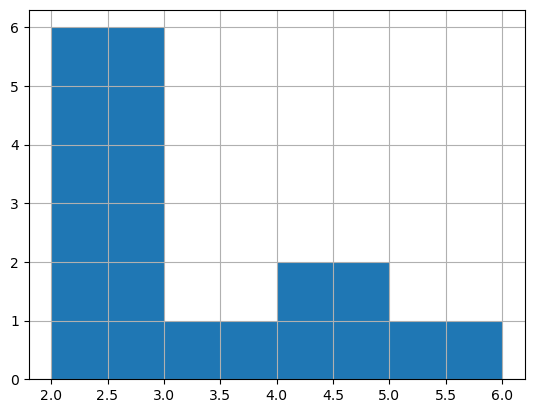

In [11]:
# Create a histogram of restaurant_groups and show plot
restaurant_groups = pd.read_csv('Data/restaurant_groups.csv')

restaurant_groups['group_size'].hist(bins = [2, 3, 4, 5, 6])
plt.show()

In [12]:
# Create probability distribution
size_dist = restaurant_groups['group_size'].value_counts() / restaurant_groups.shape[0]

# Reset index and rename columns
# Moving the index into a regular column and renaming the columns to something readable

size_dist = size_dist.reset_index()
size_dist.columns = ['group_size', 'prob']

print(size_dist)

   group_size  prob
0           2   0.6
1           4   0.2
2           6   0.1
3           3   0.1


In [13]:
# Calculate expected value
expected_value = np.sum(size_dist['group_size'] * size_dist['prob'])
print(expected_value)

2.9000000000000004


In [14]:
# Subset groups of size 4 or more
groups_4_or_more = size_dist[size_dist['group_size'] >= 4]

# Sum the probabilities of groups_4_or_more
prob_4_or_more = np.sum(groups_4_or_more['prob'])
print(prob_4_or_more)

0.30000000000000004


In [15]:
# Min and max wait times for back-up that happens every 30 min
min_time = 0
max_time = 30

# Import uniform from scipy.stats
from scipy.stats import uniform

# Calculate probability of waiting less than 5 mins
prob_less_than_5 = uniform.cdf(5, min_time, max_time)
print('prob_less_than_5:', prob_less_than_5)

# Calculate probability of waiting more than 5 mins
prob_greater_than_5 = 1 - uniform.cdf(5, min_time, max_time)
print('prob_greater_than_5:', prob_greater_than_5)

prob_less_than_5: 0.16666666666666666
prob_greater_than_5: 0.8333333333333334


In [16]:
# Calculate probability of waiting 10-20 mins
prob_between_10_and_20 = uniform.cdf(20, min_time, max_time) - uniform.cdf(10, min_time, max_time)
print(prob_between_10_and_20)

0.3333333333333333


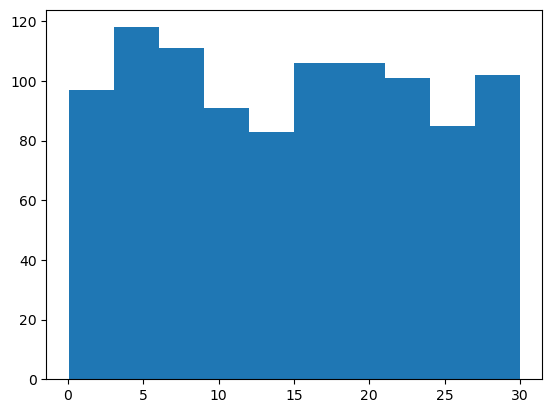

In [17]:
# Set random seed to 334
np.random.seed(334)

# Import uniform
from scipy.stats import uniform

# Generate 1000 wait times between 0 and 30 mins
wait_times = uniform.rvs(0, 30, size=1000)

# Create a histogram of simulated times and show plot
plt.hist(wait_times)
plt.show()

In [18]:
# Import binom from scipy.stats
from scipy.stats import binom

# Set random seed to 10
np.random.seed(10)

# Simulate a single deal
print(binom.rvs(1, 0.3, size=1))

# Simulate a single deal
print(binom.rvs(3, 0.3, size=1))

[1]
[0]


In [19]:
# Simulate 52 weeks of 3 deals
deals = binom.rvs(3, 0.3, size=52)

# Print mean deals won per week
print(np.mean(deals)) #In this simulated year, Amir won 0.83 deals on average each week.

0.8461538461538461


In [20]:
# Probability of closing 3 out of 3 deals
prob_3 = binom.pmf(3, 3, 0.3)
print('Probability of closing 3 out of 3 deals:', prob_3)

# Probability of closing <= 1 deal out of 3 deals
prob_less_than_or_equal_1 = binom.cdf(1, 3, 0.3)

print('Probability of closing <= 1 deal out of 3 deals:', prob_less_than_or_equal_1)
# Probability of closing > 1 deal out of 3 deals
prob_greater_than_1 = 1 - binom.cdf(1, 3, 0.3)
print('Probability of closing > 1 deal out of 3 deals:', prob_greater_than_1)

Probability of closing 3 out of 3 deals: 0.026999999999999996
Probability of closing <= 1 deal out of 3 deals: 0.784
Probability of closing > 1 deal out of 3 deals: 0.21599999999999997


In [21]:
# Expected number won with 30% win rate
won_30pct = 3 * .3
print('Expected number won with 30% win rate:', won_30pct)
# Expected number won with 25% win rate
won_25pct = 3 * 0.25
print('Expected number won with 25% win rate:', won_25pct)
# Expected number won with 35% win rate
won_35pct = 3 * 0.35
print('Expected number won with 35% win rate:', won_35pct)

Expected number won with 30% win rate: 0.8999999999999999
Expected number won with 25% win rate: 0.75
Expected number won with 35% win rate: 1.0499999999999998


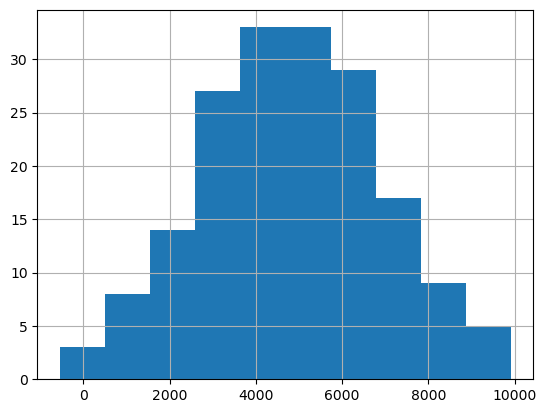

In [22]:
# Histogram of amount with 10 bins and show plot
amir_deals['amount'].hist(bins=10)
plt.show()

In [23]:
# Probability of deal < 7500
from scipy.stats import norm
prob_less_7500 = norm.cdf(7500, 5000, 2000)
print('Probability of deal < 7500:', prob_less_7500)

# Calculate the probability of a deal being less than or equal to $1000
prob_less_than_1000 = norm.cdf(1000, 5000, 2000)
# Subtract from 1 to find the probability of a deal being more than $1000
prob_over_1000 = 1 - prob_less_than_1000
print('prob_over_1000:', prob_over_1000)

Probability of deal < 7500: 0.8943502263331446
prob_over_1000: 0.9772498680518208


In [24]:
# Calculate the CDF for the upper and lower bounds
upper_bound_cdf = norm.cdf(7000, 5000, 2000)
lower_bound_cdf = norm.cdf(3000, 5000, 2000)

# Probability of deal between 3000 and 7000
prob_3000_to_7000 = upper_bound_cdf - lower_bound_cdf
print(prob_3000_to_7000)

0.6826894921370859


In [25]:
# Calculate amount that 25% of deals will be less than
pct_25 = norm.ppf(0.25, 5000, 2000)
print(pct_25)

#you can count on Amir 75% (1-0.25) of the time to make a sale worth at least $3651.02. 


3651.0204996078364


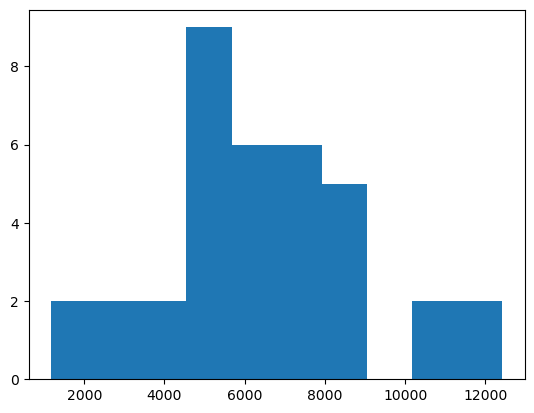

In [26]:
# Calculate new average amount
new_mean = 5000 * 1.2

# Calculate new standard deviation
new_sd = 2000 * 1.3

# Simulate 36 new sales
new_sales = norm.rvs(new_mean, new_sd, size = 36)

# Create histogram and show
plt.hist(new_sales)
plt.show()

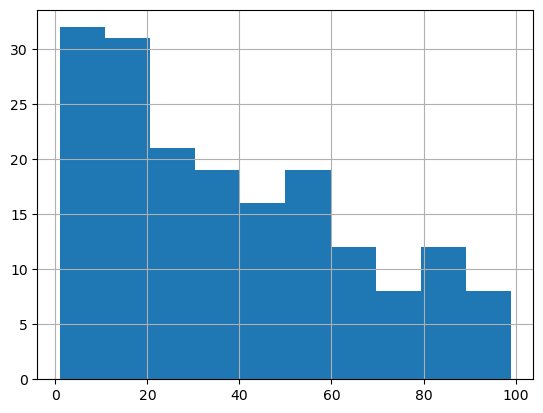

In [27]:
# Create a histogram of num_users and show
amir_deals['num_users'].hist()
plt.show()

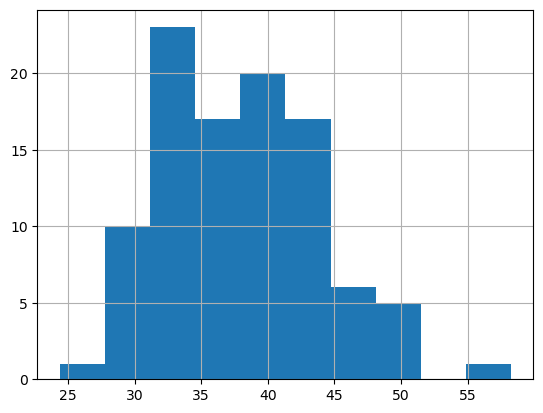

In [28]:
# Set seed to 104
np.random.seed(104)

sample_means = []
# Loop 100 times
for i in range(100):
  # Take sample of 20 num_users
  samp_20 = amir_deals['num_users'].sample(20, replace=True)
  # Calculate mean of samp_20
  samp_20_mean = np.mean(samp_20)
  # Append samp_20_mean to sample_means
  sample_means.append(samp_20_mean)
  
# Convert to Series and plot histogram
sample_means_series = pd.Series(sample_means)
sample_means_series.hist()
# Show plot
plt.show()

Even though the distribution of num_users is not normal, the distribution of its sample means resembles the normal distribution.

In [29]:
# Set seed to 321
np.random.seed(321)

sample_means = []
# Loop 30 times to take 30 means
for i in range(30):
  # Take sample of size 20 from num_users col of all_deals with replacement
  cur_sample = amir_deals['num_users'].sample(20, replace = True)
  # Take mean of cur_sample
  cur_mean = np.mean(cur_sample)
  # Append cur_mean to sample_means
  sample_means.append(cur_mean)

# Print mean of sample_means
print(np.mean(sample_means))

# Print mean of num_users in amir_deals
print(amir_deals['num_users'].mean())

38.821666666666665
37.651685393258425


In [30]:
# Import poisson from scipy.stats
from scipy.stats import poisson

# Probability of exactly 5 responses (Amir, avg=4)
prob_5 = poisson.pmf(5, 4)
print(f'prob_5: {prob_5}')

# Probability of exactly 5 responses (coworker, avg=5.5)
prob_coworker = poisson.pmf(5, 5.5)
print(f'prob_coworker: {prob_coworker}')

# Probability of 2 or fewer responses
prob_2_or_less = poisson.cdf(2, 4)
print(f'prob_2_or_less: {prob_2_or_less}')

# Probability of more than 10 responses
prob_over_10 = 1 - poisson.cdf(10, 4)
print(f'prob_over_10: {prob_over_10}')

prob_5: 0.1562934518505317
prob_coworker: 0.17140068409793663
prob_2_or_less: 0.23810330555354436
prob_over_10: 0.0028397661205137315


In [31]:
# Import expon from scipy.stats
from scipy.stats import expon
# Calculate the probability of a response time being more than 4 hours
probability_more_than_4_hours = 1 - expon.cdf(4, scale = 2.5)

# Print probability response takes > 4 hours
print('Probability_more_than_4_hours:', probability_more_than_4_hours)

# Print probability response takes 3-4 hours
prob_3 = expon.cdf(3, scale = 2.5)
prob_4 = expon.cdf(4, scale = 2.5)
print('Probability response takes 3-4 hours:', prob_4 - prob_3)

Probability_more_than_4_hours: 0.20189651799465536
Probability response takes 3-4 hours: 0.09929769391754684


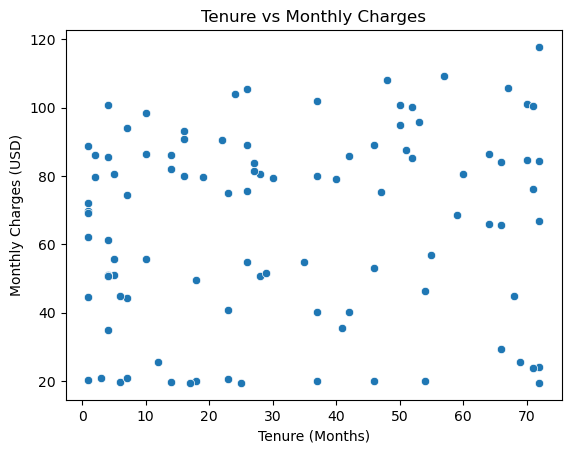

In [32]:
# import sns
import seaborn as sns

# Take 100 observations
churn_sample = churn_df.sample(100, random_state=321)

# Create a scatterplot of tenure vs. monthly charges and show
sns.scatterplot(x='tenure', y='MonthlyCharges', data=churn_sample)
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges (USD)')
plt.title('Tenure vs Monthly Charges')
plt.show()

0.13210572555321448


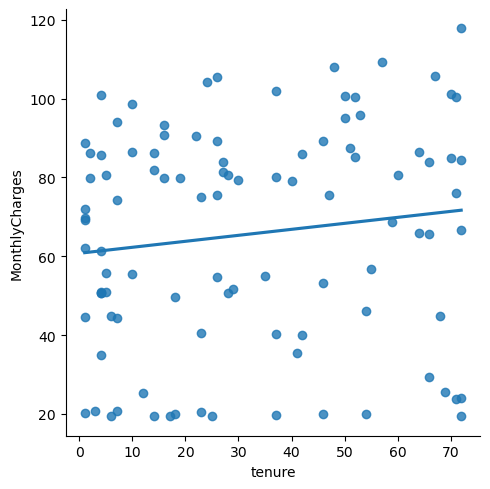

In [33]:
# Create scatterplot of tenure vs. monthly charges with trendline
sns.lmplot(x = 'tenure', y = 'MonthlyCharges', data = churn_sample, ci = None)

# Correlation between tenure and MonthlyCharges
cor = churn_sample['tenure'].corr(churn_sample['MonthlyCharges'])
print(cor)

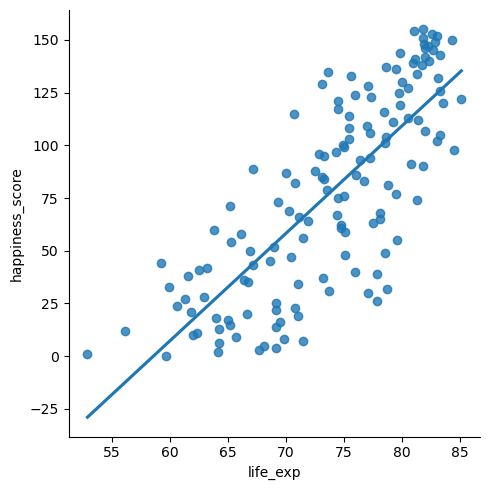

In [34]:
# Import world_happiness dataset

world_happiness = pd.read_csv('Data/world_happiness.csv')

# Create scatterplot of happiness_score vs life_exp with trendline
sns.lmplot(x = 'life_exp', y = 'happiness_score', data = world_happiness, ci = None)
# Show plot
plt.show()

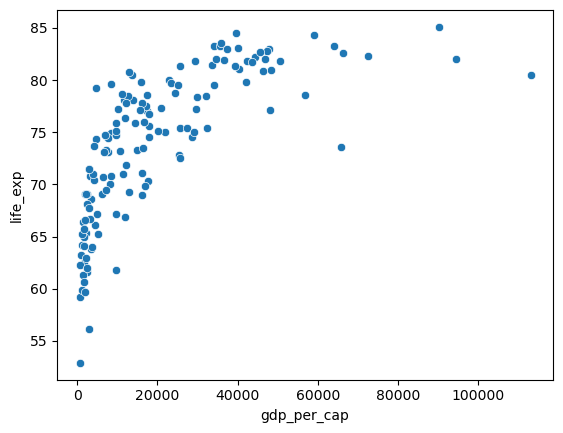

Correlation: 0.7019547642148015


In [35]:
# Scatterplot of gdp_per_cap and life_exp
sns.scatterplot(x='gdp_per_cap', y='life_exp', data=world_happiness)
# Show plot
plt.show()
  
# Correlation between gdp_per_cap and life_exp
cor = world_happiness['gdp_per_cap'].corr(world_happiness['life_exp'])
print('Correlation:', cor)
